# OLS Regression Model — HDB Resale Price Prediction

Ordinary Least Squares baseline model predicting Singapore HDB resale prices using the enriched pipeline dataset (`hdb_with_amenities_macro.csv`).

**Target variable:** `resale_price_real` (RPI-adjusted, Q4 2025 SGD base = 203.6)  
**Period:** 2021–2025  
**Final dataset:** ~134,300 transactions after cleaning

| Step | Description |
|------|-------------|
| 0 | Data exploration — flat type and flat model counts |
| 1 | Load and clean data |
| 2 | Feature engineering |
| 3 | Stratified train/test split (80/20) |
| 4 | OLS model fitting with VIF check |
| 5 | Diagnostics |
| 6 | Evaluation |

## Step 0: Data Exploration

Count of transactions by flat type and flat model from 2021 Q1 onwards.

In [1]:
import pandas as pd

df = pd.read_csv("../../merged_data/[FINAL]hdb_with_amenities_macro_pre2026.csv")

flat_type_counts = df["flat_type"].value_counts()
print(f"Total records from 2021 Q1 onwards: {len(df):,}")
print("\nCount by flat type:")
print(flat_type_counts.to_string())

flat_model_counts = df["flat_model"].value_counts()
print(f"Total records from 2021 Q1 onwards: {len(df):,}")
print("\nCount by flat model:")
print(flat_model_counts.to_string())

Total records from 2021 Q1 onwards: 134,479

Count by flat type:
flat_type
4 ROOM              57843
5 ROOM              32609
3 ROOM              31900
EXECUTIVE            8884
2 ROOM               3159
MULTI-GENERATION       43
1 ROOM                 41
Total records from 2021 Q1 onwards: 134,479

Count by flat model:
flat_model
Model A                   50770
Improved                  32322
New Generation            15279
Premium Apartment         14945
Simplified                 4897
Apartment                  4414
Standard                   3486
Maisonette                 3479
DBSS                       2056
Model A2                   1413
2-room                      361
Model A-Maisonette          241
Type S1                     219
Adjoined flat               210
Type S2                     105
Premium Apartment Loft       88
3Gen                         66
Terrace                      61
Multi Generation             43
Improved-Maisonette          15
Premium Maisonette        

## Step 1: Load and Clean Data

One cleaning operation:

1. **Drop nulls** — rows with any missing value are removed (primarily affects 89 flats with failed geocoding, which cascade to all distance columns)

In [2]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv("../../merged_data/[FINAL]hdb_with_amenities_macro_pre2026.csv")
print(f"Initial shape: {df_raw.shape}")

df = df_raw.dropna().copy()
print(f"After dropping nulls: {df.shape} (dropped {len(df_raw) - len(df)})")

n_before = len(df)
df = df.drop_duplicates().copy()
print(f"After dropping duplicates: {df.shape} (dropped {n_before - len(df)})")

df["log_resale_price_real"] = np.log(df["resale_price_real"])  # Log-transform target — preserves resale_price_real for metric computation


Initial shape: (134479, 37)
After dropping nulls: (134301, 37) (dropped 178)
After dropping duplicates: (134211, 37) (dropped 90)


## Step 2: Feature Engineering

`remaining_lease_years`, `floor_category`, `year`, and `num_primary_1km` are pre-computed in the pipeline CSV and used directly — no re-derivation needed.

**Target variable:** `log_resale_price_real` — using RPI-adjusted prices means the model captures structural flat-level pricing drivers rather than market-wide appreciation, since `year` is excluded as a feature.

Why log transformation? HDB resale prices have a heavy right tail that violates OLS normality assumptions. Applying `np.log()` compresses this tail, producing more normally distributed residuals. Coefficients in log space represent approximate percentage changes in price per unit increase in each feature, rather than dollar changes. Predictions are exponentiated back to SGD at evaluation — this gives the median predicted price, which is more robust to extreme transactions than the mean.

In [3]:
# remaining_lease_years, floor_category, year, num_primary_1km are all pre-computed in the CSV.
# No feature engineering needed — use directly.

target = "log_resale_price_real"

print(df[["remaining_lease_years", "floor_category", "year", "num_primary_1km"]].head(5))


   remaining_lease_years floor_category  year  num_primary_1km
0                64.0833            Low  2021                2
1                64.0833            Mid  2021                2
2                59.0000            Low  2021                2
3                58.1667            Low  2021                2
4                58.0833            Low  2021                2


## Step 3: Stratified Train/Validation Split (80/20)

**80/20 ratio:** With ~134,000 transactions, yields ~107,000 training and ~27,000 validation rows. The validation set is a held-out set shared across all candidate models for fair comparison — final test evaluation will be done once the best model is selected.

**Stratification key: `town + flat_type + year`** — three reasons:
1. **Town** — 26 HDB towns with substantially different price levels; random sampling could over-represent expensive towns in training.
2. **Flat type** — Highly imbalanced (4 ROOM ~43% vs 1 ROOM <0.1%); stratifying prevents minority types being underrepresented.
3. **Year** — Despite RPI adjustment, residual structural differences exist across years (post-COVID demand surge, cooling measures); ensures proportional representation of every year in both sets.

In [4]:
from sklearn.model_selection import train_test_split

df["strat_key"] = (df["town"].astype(str) + "_" +
                   df["flat_type"].astype(str) + "_" +
                   df["year"].astype(str))

strat_counts = df["strat_key"].value_counts()
valid_keys = strat_counts[strat_counts >= 2].index
n_before = len(df)
df = df[df["strat_key"].isin(valid_keys)]
print(f"Dropped {n_before - len(df)} rows with singleton strat_key combinations. Remaining: {len(df):,}")

train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["strat_key"])
print(f"Train size: {len(train_df):,} | Validation size: {len(val_df):,}")

print("Year distribution (%):")
train_year = train_df["year"].value_counts(normalize=True).sort_index().rename("Train %")
val_year = val_df["year"].value_counts(normalize=True).sort_index().rename("Val %")
year_dist = pd.concat([train_year, val_year], axis=1)
print(year_dist.map(lambda x: f"{x:.2%}"))

print("Flat type distribution (%):")
train_flat = train_df["flat_type"].value_counts(normalize=True).rename("Train %")
val_flat = val_df["flat_type"].value_counts(normalize=True).rename("Val %")
flat_dist = pd.concat([train_flat, val_flat], axis=1)
print(flat_dist.map(lambda x: f"{x:.2%}"))

Dropped 6 rows with singleton strat_key combinations. Remaining: 134,205
Train size: 107,364 | Validation size: 26,841
Year distribution (%):
     Train %   Val %
year                
2021  21.61%  21.61%
2022  19.86%  19.87%
2023  19.15%  19.16%
2024  20.71%  20.70%
2025  18.67%  18.67%
Flat type distribution (%):
                 Train %   Val %
flat_type                       
4 ROOM            43.02%  43.00%
5 ROOM            24.25%  24.23%
3 ROOM            23.71%  23.71%
EXECUTIVE          6.62%   6.63%
2 ROOM             2.35%   2.36%
1 ROOM             0.03%   0.03%
MULTI-GENERATION   0.03%   0.03%


## Step 4: Fit OLS Model

**Feature matrix (43 features total):**

| Type | Features | Treatment |
|------|----------|-----------|
| Continuous (10) | `remaining_lease_years`, `nearest_train_dist_m`, `dist_nearest_hawker_m`, `dist_nearest_primary_m`, `num_primary_1km`, `dist_nearest_park_m`, `num_parks_1km`, `dist_nearest_sportsg_m`, `dist_nearest_mall_m`, `dist_nearest_healthcare_m` | StandardScaler fit on train only; coefficients in SD units |
| Categorical — flat type (6) | 1 ROOM, 3 ROOM, 4 ROOM, 5 ROOM, EXECUTIVE, MULTI-GENERATION | One-hot; reference = 2 ROOM |
| Categorical — town (25) | All towns except ANG MO KIO | One-hot; reference = ANG MO KIO |
| Categorical — floor (2) | Mid, High | One-hot; reference = Low (floors 1–5) |

**Excluded features:**
- `floor_area_sqm` — not a user-facing input at inference time; users select flat type but do not enter exact sqm. Flat type dummies implicitly capture size.
- `dist_cbd_m` — VIF = 33.1; the 26 town fixed effects already encode CBD proximity implicitly.

In [5]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# floor_area_sqm excluded: not a user-facing input at inference time (users select flat type,
# not exact sqm). Including a feature unavailable at prediction time makes the model undeployable.
#
# dist_cbd_m excluded: VIF = 33.1 (highest in the model), indicating severe multicollinearity
# with the 26 town dummies which already encode CBD proximity implicitly.
#
# num_primary_1km: count of MOE primary schools within 1 km radius (derived from primary_schools_1km).
# Captures school density independently of nearest-school distance â€” relevant because Singapore's
# Phase 2C primary school balloting prioritises proximity, making higher school counts a distinct
# pricing signal beyond just distance to the nearest school.
continuous_features = [
    "remaining_lease_years", "nearest_train_dist_m",
    "dist_nearest_hawker_m", "dist_nearest_primary_m", "num_primary_1km", "dist_nearest_park_m",
    "dist_nearest_sportsg_m", "dist_nearest_mall_m", "dist_nearest_healthcare_m", "num_parks_1km"
]
categorical_features = ["flat_type", "town", "floor_category"]
reference_categories = {"flat_type": "2 ROOM", "town": "ANG MO KIO", "floor_category": "Low"}

# One-hot encode (drop_first=False), then manually drop reference categories
train_encoded = pd.get_dummies(train_df, columns=categorical_features, drop_first=False)
val_encoded = pd.get_dummies(val_df, columns=categorical_features, drop_first=False)

ref_cols = [f"{col}_{ref}" for col, ref in reference_categories.items()]
print(f"Dropping reference columns: {ref_cols}")
train_encoded = train_encoded.drop(columns=ref_cols, errors="ignore")
val_encoded = val_encoded.drop(columns=ref_cols, errors="ignore")

# Identify dummy columns
dummy_cols = [c for c in train_encoded.columns
              if any(c.startswith(f"{f}_") for f in categorical_features)]

# Standardise continuous features (fit on train only).
# Remaining lease is in years (0â€“99), distance features in metres (0â€“20,000) â€”
# standardising improves numerical stability of OLS.
# Dummy variables are kept as 0/1 and not standardised.
# Note: coefficients for continuous features will be in standard deviation units.
scaler = StandardScaler()
train_cont = pd.DataFrame(scaler.fit_transform(train_encoded[continuous_features]),
                           columns=continuous_features, index=train_encoded.index)
val_cont = pd.DataFrame(scaler.transform(val_encoded[continuous_features]),
                         columns=continuous_features, index=val_encoded.index)

# Cast bool dummy columns to int (pd.get_dummies returns bool in pandas 2.x)
X_train = pd.concat([train_cont, train_encoded[dummy_cols].astype(int)], axis=1)
X_val = pd.concat([val_cont, val_encoded[dummy_cols].astype(int)], axis=1)
# Align test columns to train (fill any missing with 0)
X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
y_train = train_df[target]  # Log-space targets for model training
y_val = val_df[target]
y_train_actual = train_df['resale_price_real']  # Actual SGD prices retained for metric computation and diagnostics
y_val_actual = val_df['resale_price_real']

# VIF check
vif_df = pd.DataFrame({
    "feature": X_train.columns,
    "VIF": [variance_inflation_factor(X_train.values.astype(float), i)
            for i in range(X_train.shape[1])]
}).sort_values("VIF", ascending=False).reset_index(drop=True)
high_vif = vif_df[vif_df["VIF"] > 10]
if len(high_vif) > 0:
    print("WARNING: The following features have VIF > 10. These features show high multicollinearity "
          "and their individual coefficients may be unreliable. Flagged for manual review.")
    print(high_vif.to_string(index=False))
else:
    print("VIF check passed: No features with VIF > 10.")

# Fit OLS
X_train_const = sm.add_constant(X_train)
X_val_const = sm.add_constant(X_val)
ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

Dropping reference columns: ['flat_type_2 ROOM', 'town_ANG MO KIO', 'floor_category_Low']
VIF check passed: No features with VIF > 10.
                              OLS Regression Results                             
Dep. Variable:     log_resale_price_real   R-squared:                       0.886
Model:                               OLS   Adj. R-squared:                  0.885
Method:                    Least Squares   F-statistic:                 1.931e+04
Date:                   Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                           18:13:23   Log-Likelihood:                 92106.
No. Observations:                 107364   AIC:                        -1.841e+05
Df Residuals:                     107320   BIC:                        -1.837e+05
Df Model:                             43                                         
Covariance Type:               nonrobust                                         
                                 coef    std 

## Step 5: Diagnostics

Four diagnostic checks **for documentation purposes only**. The model is not refit or modified based on results.

| Diagnostic | What to look for |
|-----------|-----------------|
| Residuals vs Fitted | Funnel shape heteroskedasticity; curve non-linearity |
| Q-Q plot | Heavy tails non-normal errors |
| Breusch-Pagan test | Formal heteroskedasticity test (p < 0.05 = detected) |
| Residuals by segment | \|mean residual\| > $30,000 systematic over/underprediction |

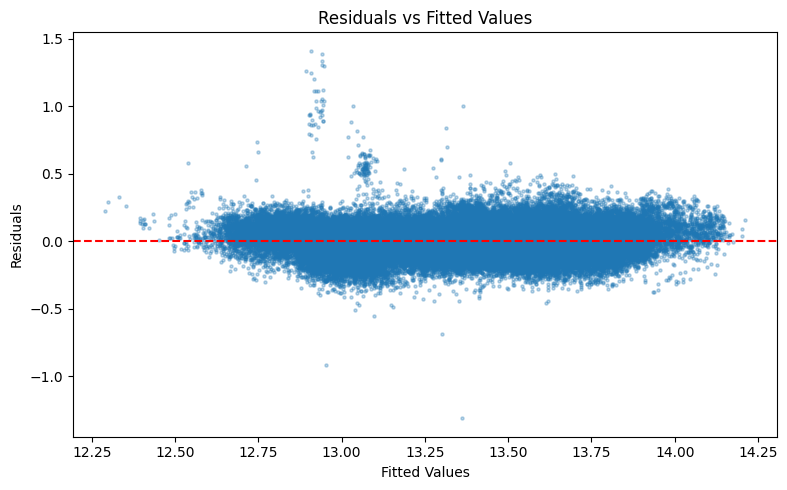

NOTE: Residuals and fitted values are in log space. Inspect for funnel shape (heteroskedasticity) or curve (non-linearity).


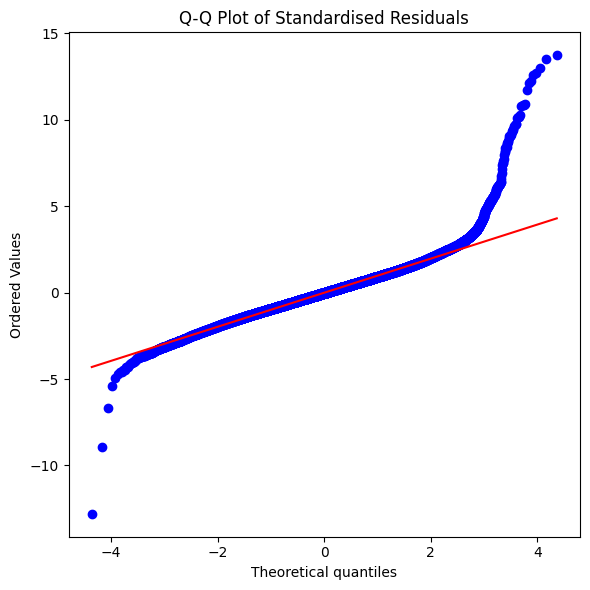

NOTE: Residuals are in log space compare to previous QQ plot to verify normality has improved.

Breusch-Pagan test: LM stat = 5141.8131, p-value = 0.0000e+00

Mean residual by town (sorted):
town
JURONG WEST        -6872.958875
PASIR RIS          -4515.823610
SEMBAWANG          -3648.324615
YISHUN             -2822.749351
TAMPINES           -2553.075442
CHOA CHU KANG      -2455.819592
WOODLANDS           -607.372203
SENGKANG             -68.780332
BUKIT BATOK          -45.659187
BUKIT PANJANG         23.650423
PUNGGOL              605.508089
HOUGANG             1004.779320
JURONG EAST         1024.835874
BEDOK               5803.896475
SERANGOON           8901.254193
ANG MO KIO          9643.881523
CLEMENTI           15536.106067
BISHAN             16105.817524
BUKIT MERAH        17335.823398
MARINE PARADE      18484.098719
KALLANG/WHAMPOA    20679.270290
GEYLANG            21341.435962
BUKIT TIMAH        23310.034828
QUEENSTOWN         24550.104426
TOA PAYOH          26089.042221
CENT

In [6]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan

y_train_pred = ols_model.predict(X_train_const)

# Log-space residuals â€” used for QQ plot, Breusch-Pagan test, residuals vs fitted
residuals_log = y_train - y_train_pred
std_resid = (residuals_log - residuals_log.mean()) / residuals_log.std()

# Actual price residuals â€” used for town and flat type systematic error breakdown
residuals_actual = y_train_actual - np.exp(y_train_pred)

# 1. Residual vs Fitted plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_train_pred, residuals_log, alpha=0.3, s=5)
ax.axhline(0, color="red", linestyle="--")
ax.set_xlabel("Fitted Values")
ax.set_ylabel("Residuals")
ax.set_title("Residuals vs Fitted Values")
plt.tight_layout()
plt.show()
print("NOTE: Residuals and fitted values are in log space. Inspect for funnel shape (heteroskedasticity) or curve (non-linearity).")

# 2. Q-Q plot
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(std_resid, dist="norm", plot=ax)
ax.set_title("Q-Q Plot of Standardised Residuals")
plt.tight_layout()
plt.show()
print("NOTE: Residuals are in log space compare to previous QQ plot to verify normality has improved.")

# 3. Breusch-Pagan test
bp_lm, bp_pvalue, _, _ = het_breuschpagan(residuals_log, X_train_const)
print(f"\nBreusch-Pagan test: LM stat = {bp_lm:.4f}, p-value = {bp_pvalue:.4e}")
if bp_pvalue < 0.05:
    print("WARNING: Heteroskedasticity detected (p < 0.05). Standard errors may be unreliable.")
else:
    print("Breusch-Pagan: No significant heteroskedasticity (p >= 0.05).")

# 4. Residuals by town and flat type
resid_df = pd.DataFrame({
    "town": train_df["town"].values,
    "flat_type": train_df["flat_type"].values,
    "residual": residuals_actual.values
})
print("\nMean residual by town (sorted):")
town_resid = resid_df.groupby("town")["residual"].mean().sort_values()
print(town_resid.to_string())
flagged_towns = town_resid[town_resid.abs() > 30000]
if len(flagged_towns) > 0:
    print(f"\nWARNING: Towns with |mean residual| > $30,000 (systematic over/underprediction):")
    print(flagged_towns.to_string())

print("\nMean residual by flat_type (sorted):")
flat_resid = resid_df.groupby("flat_type")["residual"].mean().sort_values()
print(flat_resid.to_string())
flagged_flats = flat_resid[flat_resid.abs() > 30000]
if len(flagged_flats) > 0:
    print(f"\nWARNING: Flat types with |mean residual| > $30,000 (systematic over/underprediction):")
    print(flagged_flats.to_string())

## Step 6: Evaluation

**Metrics computed on the held-out validation set (~27,000 transactions):**

| Metric | Description |
|--------|-------------|
| **RMSE** | Root Mean Squared Error — penalises large errors quadratically |
| **Linlin Loss** | Asymmetric linear loss (underprediction weight = 2.0). Underprediction penalised 2× because underestimating fair value increases the buyer's risk of paying Cash Over Valuation (COV) during negotiation. |

**Prediction intervals:** 80% intervals (10th–90th percentile) via `get_prediction().summary_frame(alpha=0.2)`. Coverage should be close to 80% for a well-calibrated model.

> Note: A composite 50/50 score across RMSE and linlin loss will be computed in a final model comparison notebook once all candidate models are evaluated.

In [7]:
def rmse(y_true, y_pred):
    return np.sqrt(np.mean((np.array(y_true) - np.array(y_pred)) ** 2))

def linlin_loss(y_true, y_pred, underpredict_weight=2.0):
    """
    Asymmetric linear loss penalising underprediction more heavily than overprediction.
    underpredict_weight=2.0 means predicted < actual is penalised at 2x.
    Overprediction is penalised at 1x.
    Rationale: Underestimating fair value increases the buyer's risk of paying
    Cash Over Valuation (COV) when negotiating price.
    """
    errors = np.array(y_true) - np.array(y_pred)  # positive = underprediction
    loss = np.where(errors > 0, underpredict_weight * errors, -errors)
    return np.mean(loss)

y_val_pred_log = ols_model.predict(X_val_const)
y_val_pred = np.exp(y_val_pred_log)  # median prediction — no Duan correction applied
val_rmse = rmse(y_val_actual, y_val_pred)
val_linlin = linlin_loss(y_val_actual, y_val_pred, underpredict_weight=2.0)

print("=== OLS MODEL EVALUATION (VALIDATION SET) ===")
print(f"RMSE:          ${val_rmse:,.0f}")
print(f"Linlin Loss:   ${val_linlin:,.0f} (underpredict weight = 2.0)")
print()
print("NOTE: Composite 50/50 scoring across models will be computed in the")
print("final comparison notebook once all models are evaluated.")

# 80% prediction intervals (alpha=0.2 → 10th–90th percentile)
pred_frame = ols_model.get_prediction(X_val_const).summary_frame(alpha=0.2)
pi_lower = np.exp(pred_frame['obs_ci_lower'].values)
pi_upper = np.exp(pred_frame['obs_ci_upper'].values)
coverage = ((y_val_actual.values >= pi_lower) & (y_val_actual.values <= pi_upper)).mean()
print(f"80% Prediction Interval Coverage: {coverage:.1%}")
if coverage < 0.70:
    print("WARNING: Coverage < 70%. Prediction intervals are too narrow — model may be overconfident.")
elif coverage > 0.90:
    print("WARNING: Coverage > 90%. Prediction intervals are too wide — model may be underconfident.")
else:
    print("Coverage within expected range (70%–90%).")

=== OLS MODEL EVALUATION (VALIDATION SET) ===
RMSE:          $74,439
Linlin Loss:   $81,649 (underpredict weight = 2.0)

NOTE: Composite 50/50 scoring across models will be computed in the
final comparison notebook once all models are evaluated.
80% Prediction Interval Coverage: 83.1%
Coverage within expected range (70%–90%).


## Results Summary

| Metric | Value |
|--------|-------|
| R² (train, log space) | 0.885 |
| Adj. R² (train, log space) | 0.885 |
| RMSE (validation, SGD) | $74,439 |
| Linlin Loss (validation, SGD, w=2) | $81,649 |
| 80% PI Coverage | 83.1% ✓ (within 70–90% expected range) |

**VIF check:** All 43 features passed (no VIF > 10) after excluding `floor_area_sqm` and `dist_cbd_m`.

**Diagnostics:**
- Breusch-Pagan: heteroskedasticity expected (housing price variance tends to be larger for expensive flats)
- Residuals by town and flat type: mean training residuals are ~0 by construction in OLS

## Step 7: Save Model Artifacts

Serialize the fitted OLS model, scaler, and feature column list so they can be loaded by `backend/trial_predict.py` without re-fitting.

In [8]:
'''
import joblib
import json
from pathlib import Path

MODEL_DIR = Path(".")  # same directory as this notebook: backend/price_model/

# Save statsmodels OLS model.
# remove_data=True strips the 107k-row training arrays (endog/exog) from the
# pickle — reduces file size from ~113 MB to ~1 MB. get_prediction() still
# works because it only needs the fitted params and covariance matrix.
ols_model.save(str(MODEL_DIR / "ols_model.pkl"), remove_data=True)

# Save sklearn StandardScaler
joblib.dump(scaler, MODEL_DIR / "ols_scaler.joblib")

# Save ordered feature column list — critical for correct column ordering at inference
with open(MODEL_DIR / "ols_feature_cols.json", "w") as f:
    json.dump(list(X_train.columns), f)

print("Saved:")
print(f"  {MODEL_DIR / 'ols_model.pkl'}")
print(f"  {MODEL_DIR / 'ols_scaler.joblib'}")
print(f"  {MODEL_DIR / 'ols_feature_cols.json'}")
'''

'\nimport joblib\nimport json\nfrom pathlib import Path\n\nMODEL_DIR = Path(".")  # same directory as this notebook: backend/price_model/\n\n# Save statsmodels OLS model.\n# remove_data=True strips the 107k-row training arrays (endog/exog) from the\n# pickle — reduces file size from ~113 MB to ~1 MB. get_prediction() still\n# works because it only needs the fitted params and covariance matrix.\nols_model.save(str(MODEL_DIR / "ols_model.pkl"), remove_data=True)\n\n# Save sklearn StandardScaler\njoblib.dump(scaler, MODEL_DIR / "ols_scaler.joblib")\n\n# Save ordered feature column list — critical for correct column ordering at inference\nwith open(MODEL_DIR / "ols_feature_cols.json", "w") as f:\n    json.dump(list(X_train.columns), f)\n\nprint("Saved:")\nprint(f"  {MODEL_DIR / \'ols_model.pkl\'}")\nprint(f"  {MODEL_DIR / \'ols_scaler.joblib\'}")\nprint(f"  {MODEL_DIR / \'ols_feature_cols.json\'}")\n'